# Part 2: Hands-On Engineering

This notebook demonstrates implementation using **Polars** (with Pandas equivalents in comments).

Data file: `data/fashion_sample.csv`

## Data Context

**Dataset:** `data/fashion_sample.csv`  
**Coverage:** 100 days of data for one product at one store

**Columns:**
- `date` - Date of observation
- `style` - Product style identifier
- `site` - Store/site identifier
- `sales` - Units sold
- `inventory` - Stock on hand
- `original_price` - Original/list price
- `current_price` - Current selling price
- `cost` - Product cost
- `launch_date` - Product launch date

**Data Periods:**
- **Days 1-40:** Normal sales period
- **Days 41-50:** Stockout period (inventory=0)
- **Days 70+:** Markdown period (price drops)

**Note:** Dataset contains intentional data quality issues to reflect real-world scenarios.

## Setup and Imports

In [2]:
# Import required libraries
import polars as pl
# import pandas as pd  # Pandas equivalent

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pl.Config.set_tbl_rows(20)
# pd.set_option('display.max_rows', 20)  # Pandas

print(f"Polars version: {pl.__version__}")
print("Setup complete!")

Polars version: 1.38.0
Setup complete!


## Task 4: Analysis & Features

### Part A: Exploration

Loading the dataset using Polars and Pandas for comparison.

In [23]:
# Load the data
df = pl.read_csv("data/fashion_sample.csv")
# df = pd.read_csv("data/fashion_sample.csv")  # Pandas

print(f"Shape: {df.shape}")
df.head()

Shape: (100, 9)


date,style,site,sales,inventory,original_price,current_price,cost,launch_date
str,str,str,i64,i64,f64,f64,f64,str
"""2024-01-01""","""ATH-RUN-2024-BLK""","""STORE_001""",12,450,129.99,129.99,45.5,"""2023-12-15"""
"""2024-01-02""","""ATH-RUN-2024-BLK""","""STORE_001""",8,442,129.99,129.99,45.5,"""2023-12-15"""
"""2024-01-03""","""ATH-RUN-2024-BLK""","""STORE_001""",15,427,129.99,129.99,45.5,"""2023-12-15"""
"""2024-01-04""","""ATH-RUN-2024-BLK""","""STORE_001""",11,416,129.99,129.99,45.5,"""2023-12-15"""
"""2024-01-05""","""ATH-RUN-2024-BLK""","""STORE_001""",19,397,129.99,129.99,45.5,"""2023-12-15"""


In [24]:
# Convert date columns to proper types and extract date features
df = df.with_columns([
    pl.col("date").str.to_date().alias("date"),
    pl.col("launch_date").str.to_date().alias("launch_date")
])

# Add day_number column (Day 1, Day 2, ..., Day N)
df = df.with_columns([
    (pl.col("date").rank(method="dense") - 1 + 1).cast(pl.Int32).alias("day_number")
])
# Pandas equivalent:
# df['day_number'] = (df['date'] - df['date'].min()).dt.days + 1


# Extract 'date' feature as integers
df = df.with_columns([
    pl.col("date").dt.day().alias("date_day"),
    pl.col("date").dt.month().alias("date_month"),
    pl.col("date").dt.year().alias("date_year"),
    pl.col("date").dt.weekday().alias("date_weekday")
])

# Extract 'launch_date' feature as integers
df = df.with_columns([
    pl.col("launch_date").dt.day().alias("launch_date_day"),
    pl.col("launch_date").dt.month().alias("launch_date_month"),
    pl.col("launch_date").dt.year().alias("launch_date_year"),
    pl.col("launch_date").dt.weekday().alias("launch_date_weekday")
])

# Pandas equivalent for date features:
# df['date'] = pd.to_datetime(df['date'])
# df['launch_date'] = pd.to_datetime(df['launch_date'])
# df['date_day'] = df['date'].dt.day
# df['date_month'] = df['date'].dt.month
# df['date_year'] = df['date'].dt.year
# df['date_weekday'] = df['date'].dt.weekday

print("Date columns converted, day_number added, and components extracted:")

print(f"Date range: Day 1 ({df['date'].min()}) to Day {df['day_number'].max()} ({df['date'].max()})")

df.select(["date", "day_number", "date_day", "date_month", "date_year", "date_weekday", "launch_date", "launch_date_day", "launch_date_month", "launch_date_year", "launch_date_weekday"]).head(10)

Date columns converted, day_number added, and components extracted:
Date range: Day 1 (2024-01-01) to Day 100 (2024-04-09)


date,day_number,date_day,date_month,date_year,date_weekday,launch_date,launch_date_day,launch_date_month,launch_date_year,launch_date_weekday
date,i32,i8,i8,i32,i8,date,i8,i8,i32,i8
2024-01-01,1,1,1,2024,1,2023-12-15,15,12,2023,5
2024-01-02,2,2,1,2024,2,2023-12-15,15,12,2023,5
2024-01-03,3,3,1,2024,3,2023-12-15,15,12,2023,5
2024-01-04,4,4,1,2024,4,2023-12-15,15,12,2023,5
2024-01-05,5,5,1,2024,5,2023-12-15,15,12,2023,5
2024-01-06,6,6,1,2024,6,2023-12-15,15,12,2023,5
2024-01-07,7,7,1,2024,7,2023-12-15,15,12,2023,5
2024-01-08,8,8,1,2024,1,2023-12-15,15,12,2023,5
2024-01-09,9,9,1,2024,2,2023-12-15,15,12,2023,5


In [25]:
df.describe()

statistic,date,style,site,sales,inventory,original_price,current_price,cost,launch_date,day_number,date_day,date_month,date_year,date_weekday,launch_date_day,launch_date_month,launch_date_year,launch_date_weekday
str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""100""","""100""","""100""",99.0,100.0,100.0,100.0,100.0,"""100""",100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
"""null_count""","""0""","""0""","""0""",1.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2024-02-19 12:00:00""",null,null,9.111111,79.19,129.99,111.89,45.5,"""2023-12-15 00:00:00""",50.5,14.72,2.18,2024.0,3.95,15.0,12.0,2023.0,5.0
"""std""",null,null,null,9.381798,123.304067,0.0,29.360009,0.0,null,29.011492,8.991668,0.978352,0.0,2.021975,0.0,0.0,0.0,0.0
"""min""","""2024-01-01""","""ATH-RUN-2024-BLK""","""STORE_001""",0.0,0.0,129.99,49.99,45.5,"""2023-12-15""",1.0,1.0,1.0,2024.0,1.0,15.0,12.0,2023.0,5.0
"""25%""","""2024-01-26""",null,null,0.0,0.0,129.99,99.99,45.5,"""2023-12-15""",26.0,7.0,1.0,2024.0,2.0,15.0,12.0,2023.0,5.0
"""50%""","""2024-02-20""",null,null,8.0,15.0,129.99,129.99,45.5,"""2023-12-15""",51.0,14.0,2.0,2024.0,4.0,15.0,12.0,2023.0,5.0
"""75%""","""2024-03-15""",null,null,15.0,104.0,129.99,129.99,45.5,"""2023-12-15""",75.0,22.0,3.0,2024.0,6.0,15.0,12.0,2023.0,5.0
"""max""","""2024-04-09""","""ATH-RUN-2024-BLK""","""STORE_001""",42.0,450.0,129.99,129.99,45.5,"""2023-12-15""",100.0,31.0,4.0,2024.0,7.0,15.0,12.0,2023.0,5.0


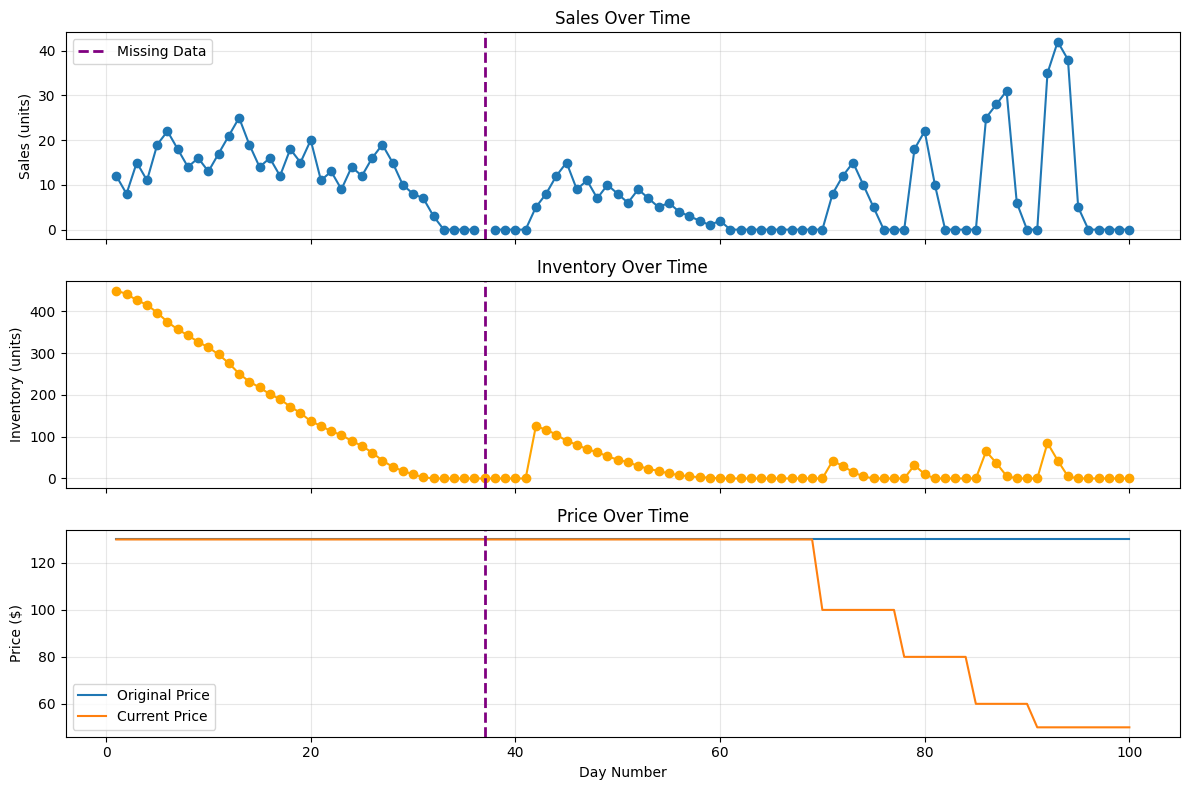

In [31]:
# Plot sales and inventory over time using day_number on x-axis
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Convert to pandas for plotting (Polars -> Pandas conversion) (Polars doesn’t provide direct matplotlib plotting helpers)
df_pd = df.to_pandas()

# Find the day with null sales value
null_sales_day = df_pd[df_pd['sales'].isna()]['day_number'].values
if len(null_sales_day) > 0:
    null_day = null_sales_day[0]
    print(f"Warning: Found null sales value on Day {null_day}")
else:
    null_day = None

# Sales
axes[0].plot(df_pd['day_number'], df_pd['sales'], marker='o', linewidth=1.5)
axes[0].set_ylabel('Sales (units)')
axes[0].set_title('Sales Over Time')
axes[0].grid(alpha=0.3)
if null_day is not None:
    axes[0].axvline(x=null_day, color='purple', linestyle='--', linewidth=2, label='Missing Data')
axes[0].legend()

# Inventory
axes[1].plot(df_pd['day_number'], df_pd['inventory'], marker='o', linewidth=1.5, color='orange')
axes[1].set_ylabel('Inventory (units)')
axes[1].set_title('Inventory Over Time')
axes[1].grid(alpha=0.3)
if null_day is not None:
    axes[1].axvline(x=null_day, color='purple', linestyle='--', linewidth=2)

# Price
axes[2].plot(df_pd['day_number'], df_pd['original_price'], label='Original Price', linewidth=1.5)
axes[2].plot(df_pd['day_number'], df_pd['current_price'], label='Current Price', linewidth=1.5)
axes[2].set_ylabel('Price ($)')
axes[2].set_xlabel('Day Number')
axes[2].set_title('Price Over Time')
axes[2].legend()
axes[2].grid(alpha=0.3)
if null_day is not None:
    axes[2].axvline(x=null_day, color='purple', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

We can tell that there is a data quality issue with one day (day 37) not capturing a sales data point. Thankfully, the inventory at day 37 was zero, so if we must create syntehtic data for sales that day we can assume it is also zero. My condifence also stems from looking at the day before and after. It can affect forecst accuracy as no sales doesn't (null) doesn't mean that the demand was inexistent (0). Even a zero sale doesn't mean low demand. In this case, it is an affect of no inventory left to produce a sale. Classic demand censoring problem that can arise in the forcast. We can also simply observe a clear spike in slaes due to price discounts but when the item quicly sold out thanks to the discounted price, inventories dropped and was not replensihed in time. There is correlation here with price going down, sales up and inventory clearing out to zero. The stokout period begins when inventry falls to zero until we replenish. Obvously, sales collapse with the stockout period. The trend of sales has strucutre that is consistent with inventory in the beginning but its strucutre breaks when stockout periods happen and sharp repleneshing. Sales strucutre also breaks when markdowns happen. For modeiling, we can treat stockout days in their special period with includeing falgs for it. The null day can be synthetically filled or ignored with flags. We can model with inclusion or exclusion of stockout periods or pattern breaking periods in sales. Flags and includsions can be pre and post stockouts and pre and post discount period. With this we can capture demand in response to discounts. 

First stockout day (inventory = 0): Day 32
Last stockout day: Day 100

Zooming into stockout period: Days 30-104
Stockout period: Days 32-100
Data points: 71


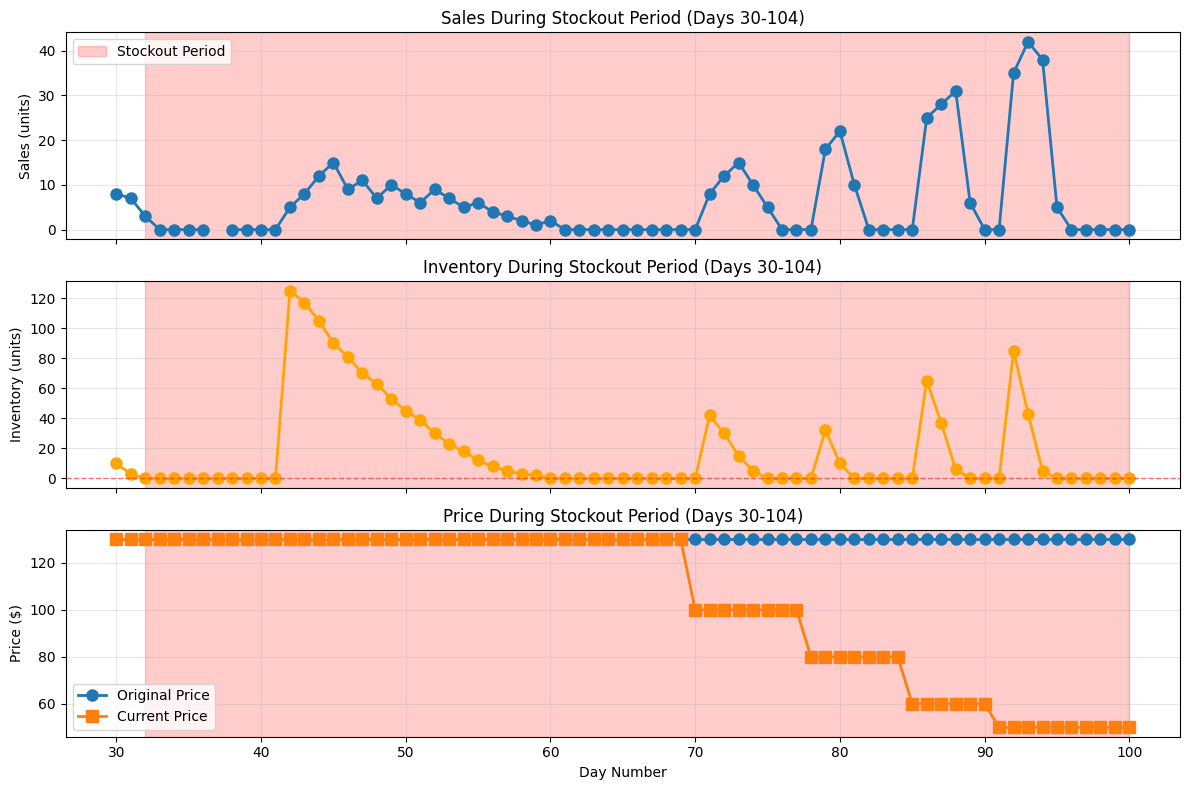


Summary for Stockout Period:
Average Sales (2 days before stockout, Days 30-31): 7.50
Average Sales (during stockout, Days 32-100): 6.51
Average Sales (4 days after stockout, Days 101-104): nan


In [30]:
# Focus on stockout period: Find when inventory first reaches 0, then show ±buffer days

# Find the first day when inventory reaches 0
first_stockout_day = df_pd[df_pd['inventory'] == 0]['day_number'].min()
print(f"First stockout day (inventory = 0): Day {first_stockout_day}")

# Find the last day of stockout
last_stockout_day = df_pd[df_pd['inventory'] == 0]['day_number'].max()
print(f"Last stockout day: Day {last_stockout_day}")

# Set buffer: 2 days before first stockout, 4 days after last stockout
buffer_before = 2
buffer_after = 4

filter_start = first_stockout_day - buffer_before
filter_end = last_stockout_day + buffer_after

df_stockout = df_pd[(df_pd['day_number'] >= filter_start) & (df_pd['day_number'] <= filter_end)]

print(f"\nZooming into stockout period: Days {filter_start}-{filter_end}")
print(f"Stockout period: Days {first_stockout_day}-{last_stockout_day}")
print(f"Data points: {len(df_stockout)}")

# Plot zoomed-in view of stockout period
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Sales
axes[0].plot(df_stockout['day_number'], df_stockout['sales'], marker='o', linewidth=2, markersize=8)
axes[0].set_ylabel('Sales (units)')
axes[0].set_title(f'Sales During Stockout Period (Days {filter_start}-{filter_end})')
axes[0].grid(alpha=0.3)
axes[0].axvspan(first_stockout_day, last_stockout_day, alpha=0.2, color='red', label='Stockout Period')
axes[0].legend()

# Inventory
axes[1].plot(df_stockout['day_number'], df_stockout['inventory'], marker='o', linewidth=2, markersize=8, color='orange')
axes[1].set_ylabel('Inventory (units)')
axes[1].set_title(f'Inventory During Stockout Period (Days {filter_start}-{filter_end})')
axes[1].grid(alpha=0.3)
axes[1].axvspan(first_stockout_day, last_stockout_day, alpha=0.2, color='red')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Price
axes[2].plot(df_stockout['day_number'], df_stockout['original_price'], label='Original Price', linewidth=2, markersize=8, marker='o')
axes[2].plot(df_stockout['day_number'], df_stockout['current_price'], label='Current Price', linewidth=2, markersize=8, marker='s')
axes[2].set_ylabel('Price ($)')
axes[2].set_xlabel('Day Number')
axes[2].set_title(f'Price During Stockout Period (Days {filter_start}-{filter_end})')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].axvspan(first_stockout_day, last_stockout_day, alpha=0.2, color='red')

plt.tight_layout()
plt.show()

# Print summary statistics for this period
print(f"\nSummary for Stockout Period:")
print(f"Average Sales (2 days before stockout, Days {filter_start}-{first_stockout_day-1}): {df_stockout[df_stockout['day_number'] < first_stockout_day]['sales'].mean():.2f}")
print(f"Average Sales (during stockout, Days {first_stockout_day}-{last_stockout_day}): {df_stockout[(df_stockout['day_number'] >= first_stockout_day) & (df_stockout['day_number'] <= last_stockout_day)]['sales'].mean():.2f}")
print(f"Average Sales (4 days after stockout, Days {last_stockout_day+1}-{filter_end}): {df_stockout[df_stockout['day_number'] > last_stockout_day]['sales'].mean():.2f}")

### Part B: Visualize Sales, Inventory & Price Over Time

In [ ]:
# Identify markdown period (current_price < original_price)
markdown_days = df.filter(pl.col("current_price") < pl.col("original_price"))
print(f"Markdown days: {len(markdown_days)}")
markdown_days.head()
# df[df['current_price'] < df['original_price']]  # Pandas

In [ ]:
# Identify stockout period (inventory = 0)
stockout_days = df.filter(pl.col("inventory") == 0)
print(f"Stockout days: {len(stockout_days)}")
stockout_days
# df[df['inventory'] == 0]  # Pandas

In [ ]:
# Check nulls
df.null_count()
# df.isnull().sum()  # Pandas

### Missing Values & Data Quality

In [ ]:
# Descriptive stats
df.describe()
# df.describe()  # Pandas

### Summary Statistics

In [ ]:
# Check column types
print(df.schema)
# print(df.dtypes)  # Pandas

# Convert date columns
df = df.with_columns(pl.col("date").str.to_date())
# df['date'] = pd.to_datetime(df['date'])  # Pandas

df.head()

### Data Schema & Types

## Task 5: [Awaiting question]

In [ ]:
# Task 5 implementation will go here